In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

In [2]:
current_dir = Path.cwd()

if (current_dir / "data").exists():
    project_root = current_dir
elif (current_dir.parent / "data").exists():
    project_root = current_dir.parent
else:
    raise FileNotFoundError(
        f"Cannot find project root. Current directory: {current_dir}"
    )

data_path = (
    project_root
    / "data"
    / "processed"
    / "dst_reviews_english_text.csv"
)

figures_dir = project_root / "outputs" / "figures"
tables_dir = project_root / "outputs" / "tables"

figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

model_df = pd.read_csv(data_path)

print("Data shape:", model_df.shape)
print("Data path:", data_path)

Data shape: (4511, 29)
Data path: /Users/zhouzhou/Desktop/dst-review-analysis/data/processed/dst_reviews_english_text.csv


In [3]:
if not pd.api.types.is_bool_dtype(model_df["voted_up"]):
    model_df["voted_up"] = (
        model_df["voted_up"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(
            {
                "true": True,
                "false": False,
                "1": True,
                "0": False,
            }
        )
    )

model_df = model_df.dropna(
    subset=["review", "voted_up"]
).copy()

model_df["review"] = (
    model_df["review"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

model_df = model_df[
    model_df["review"].ne("")
].copy()

model_df["target"] = (
    model_df["voted_up"]
    .astype(int)
)

print("Model data shape:", model_df.shape)
print("\nTarget distribution:")
print(model_df["target"].value_counts())

print("\nTarget percentages:")
print(
    model_df["target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Model data shape: (4511, 30)

Target distribution:
target
1    4093
0     418
Name: count, dtype: int64

Target percentages:
target
1    90.73
0     9.27
Name: proportion, dtype: float64


In [4]:
X = model_df["review"]
y = model_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training reviews:", len(X_train))
print("Test reviews:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())

Training reviews: 3608
Test reviews: 903

Training target distribution:
target
1    3274
0     334
Name: count, dtype: int64

Test target distribution:
target
1    819
0     84
Name: count, dtype: int64


In [5]:
baseline_model = DummyClassifier(
    strategy="most_frequent",
)

baseline_model.fit(
    X_train.to_frame(),
    y_train,
)

baseline_predictions = baseline_model.predict(
    X_test.to_frame()
)

print(
    classification_report(
        y_test,
        baseline_predictions,
        target_names=[
            "Not recommended",
            "Recommended",
        ],
        zero_division=0,
    )
)

                 precision    recall  f1-score   support

Not recommended       0.00      0.00      0.00        84
    Recommended       0.91      1.00      0.95       819

       accuracy                           0.91       903
      macro avg       0.45      0.50      0.48       903
   weighted avg       0.82      0.91      0.86       903



基准分类器将每条测试评论都预测为推荐。由于正面评论在数据集中占主导地位，其准确率达到了90.7%。
然而，该模型未识别出84条不推荐的评论。负类的召回率和F1分数均为零。因此，仅使用准确率作为评估指标并不适用于这个不平衡的数据集。

In [6]:
text_model = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                token_pattern=(
                    r"(?u)\b[a-zA-Z][a-zA-Z']+\b"
                ),
                ngram_range=(1, 2),
                min_df=3,
                max_df=0.95,
                sublinear_tf=True,
            ),
        ),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=42,
            ),
        ),
    ]
)

text_model

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, min_df=3, ngram_range=(1, 2),
                                 sublinear_tf=True,
                                 token_pattern="(?u)\\b[a-zA-Z][a-zA-Z']+\\b")),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

In [7]:
text_model.fit(
    X_train,
    y_train,
)

model_predictions = text_model.predict(
    X_test
)

print("Model training completed.")

Model training completed.


In [8]:
model_report = classification_report(
    y_test,
    model_predictions,
    target_names=[
        "Not recommended",
        "Recommended",
    ],
    zero_division=0,
)

print(model_report)

                 precision    recall  f1-score   support

Not recommended       0.39      0.68      0.50        84
    Recommended       0.96      0.89      0.93       819

       accuracy                           0.87       903
      macro avg       0.68      0.79      0.71       903
   weighted avg       0.91      0.87      0.89       903



In [9]:
confusion = confusion_matrix(
    y_test,
    model_predictions,
    labels=[0, 1],
)

confusion

array([[ 57,  27],
       [ 88, 731]])

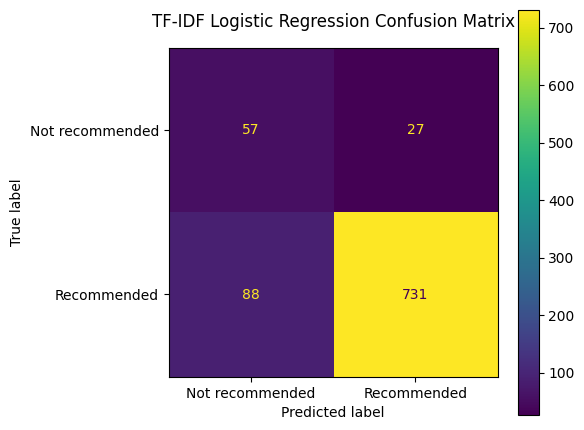

In [10]:
figure, axis = plt.subplots(figsize=(6, 5))

confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=[
        "Not recommended",
        "Recommended",
    ],
)

confusion_display.plot(
    ax=axis,
    values_format="d",
)

axis.set_title(
    "TF-IDF Logistic Regression Confusion Matrix",
    pad=15,
)

figure.tight_layout()

figure.savefig(
    figures_dir / "13_logistic_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [11]:
model_report_df = pd.DataFrame(
    classification_report(
        y_test,
        model_predictions,
        target_names=[
            "Not recommended",
            "Recommended",
        ],
        zero_division=0,
        output_dict=True,
    )
).transpose()

model_report_df.round(3)

,precision,recall,f1-score,support
Not recommended,0.393,0.679,0.498,84.000
Recommended,0.964,0.893,0.927,819.000
accuracy,0.873,0.873,0.873,0.873
macro avg,0.679,0.786,0.712,903.000
weighted avg,0.911,0.873,0.887,903.000


In [12]:
model_report_df.to_csv(
    tables_dir / "logistic_regression_report.csv"
)

print("Model report saved.")

Model report saved.


TF-IDF 逻辑回归模型的准确率为 87.3%。虽然低于基线模型的 90.7%，但基线模型只是把所有评论都预测为推荐，因此完全无法识别差评。
逻辑回归模型成功识别了 84 条真实差评中的 57 条，差评召回率达到 67.9%。差评类别的 F1-score 从基线模型的 0 提升到 0.498，宏平均 F1-score 也从约 0.48 提升到 0.712。
模型同时把 88 条真实好评误判为差评。这说明在使用类别平衡权重后，模型对差评更加敏感，但也产生了更多误报。
在本项目中，宏平均 F1-score 和差评召回率比准确率更有参考价值，因为数据中的好评数量远多于差评。

In [13]:
tfidf_vectorizer = text_model.named_steps["tfidf"]
logistic_classifier = text_model.named_steps["classifier"]

feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients = logistic_classifier.coef_[0]

feature_importance = pd.DataFrame(
    {
        "term": feature_names,
        "coefficient": coefficients,
    }
)

print("Number of text features:", len(feature_importance))

feature_importance.head()

Number of text features: 5872


,term,coefficient
0,abilities,-0.417100
1,abilities that,-0.130770
2,ability,0.101304
3,able,0.124884
4,able to,0.124884


In [14]:
top_positive_features = (
    feature_importance
    .nlargest(20, "coefficient")
    .reset_index(drop=True)
)

top_positive_features.round(3)

,term,coefficient
0,fun,3.965
1,good,3.197
2,love,2.907
3,friends,2.494
4,great,2.494
5,best,2.478
6,starve,2.110
7,nice,1.983
8,amazing,1.925
9,cool,1.876


In [15]:
top_negative_features = (
    feature_importance
    .nsmallest(20, "coefficient")
    .reset_index(drop=True)
)

top_negative_features.round(3)

,term,coefficient
0,not,-4.560
1,boring,-4.143
2,no,-3.519
3,trash,-3.142
4,bad,-2.736
5,too,-2.376
6,worst,-2.356
7,ahh,-2.348
8,friendslop,-2.140
9,do not,-1.939


In [16]:
top_positive_features.to_csv(
    tables_dir / "model_positive_features.csv",
    index=False,
)

top_negative_features.to_csv(
    tables_dir / "model_negative_features.csv",
    index=False,
)

print("Model feature tables saved.")

Model feature tables saved.


In [17]:
import numpy as np

tfidf_matrix_train = (
    text_model.named_steps["tfidf"]
    .transform(X_train)
)

document_frequency = np.asarray(
    (tfidf_matrix_train > 0).sum(axis=0)
).ravel()

feature_importance = pd.DataFrame(
    {
        "term": feature_names,
        "coefficient": coefficients,
        "training_review_count": document_frequency,
    }
)

feature_importance.head()

,term,coefficient,training_review_count
0,abilities,-0.417100,9
1,abilities that,-0.130770,3
2,ability,0.101304,4
3,able,0.124884,18
4,able to,0.124884,18


In [18]:
from IPython.display import display as ipy_display

stable_features = feature_importance.loc[
    feature_importance["training_review_count"] >= 10
].copy()

stable_positive_features = (
    stable_features
    .nlargest(15, "coefficient")
    .reset_index(drop=True)
)

stable_negative_features = (
    stable_features
    .nsmallest(15, "coefficient")
    .reset_index(drop=True)
)

print("稳定的正面特征")
ipy_display(stable_positive_features.round(3))

print("稳定的负面特征")
ipy_display(stable_negative_features.round(3))

稳定的正面特征


,term,coefficient,training_review_count
0,fun,3.965,675
1,good,3.197,480
2,love,2.907,292
3,friends,2.494,456
4,great,2.494,217
5,best,2.478,174
6,starve,2.110,258
7,nice,1.983,100
8,amazing,1.925,97
9,cool,1.876,100


稳定的负面特征


,term,coefficient,training_review_count
0,not,-4.560,314
1,boring,-4.143,41
2,no,-3.519,161
3,trash,-3.142,12
4,bad,-2.736,54
5,too,-2.376,112
6,worst,-2.356,18
7,do not,-1.939,29
8,why,-1.928,43
9,just,-1.870,271


In [19]:
selected_positive_terms = [
    "fun",
    "good",
    "love",
    "friends",
    "great",
    "best",
    "nice",
    "amazing",
    "cool",
    "love this",
    "good game",
    "survival",
]

selected_negative_terms = [
    "not",
    "boring",
    "no",
    "trash",
    "bad",
    "too",
    "worst",
    "do not",
    "why",
    "hate",
]

final_positive_features = (
    feature_importance.loc[
        feature_importance["term"].isin(
            selected_positive_terms
        )
    ]
    .sort_values(
        "coefficient",
        ascending=False,
    )
    .reset_index(drop=True)
)

final_negative_features = (
    feature_importance.loc[
        feature_importance["term"].isin(
            selected_negative_terms
        )
    ]
    .sort_values(
        "coefficient",
        ascending=True,
    )
    .reset_index(drop=True)
)

print("最终正面特征")
ipy_display(final_positive_features.round(3))

print("最终负面特征")
ipy_display(final_negative_features.round(3))

最终正面特征


,term,coefficient,training_review_count
0,fun,3.965,675
1,good,3.197,480
2,love,2.907,292
3,friends,2.494,456
4,great,2.494,217
5,best,2.478,174
6,nice,1.983,100
7,amazing,1.925,97
8,cool,1.876,100
9,love this,1.693,81


最终负面特征


,term,coefficient,training_review_count
0,not,-4.560,314
1,boring,-4.143,41
2,no,-3.519,161
3,trash,-3.142,12
4,bad,-2.736,54
5,too,-2.376,112
6,worst,-2.356,18
7,do not,-1.939,29
8,why,-1.928,43
9,hate,-1.636,46


In [20]:
final_positive_features.to_csv(
    tables_dir / "final_model_positive_features.csv",
    index=False,
)

final_negative_features.to_csv(
    tables_dir / "final_model_negative_features.csv",
    index=False,
)

print("最终特征表已保存。")

最终特征表已保存。


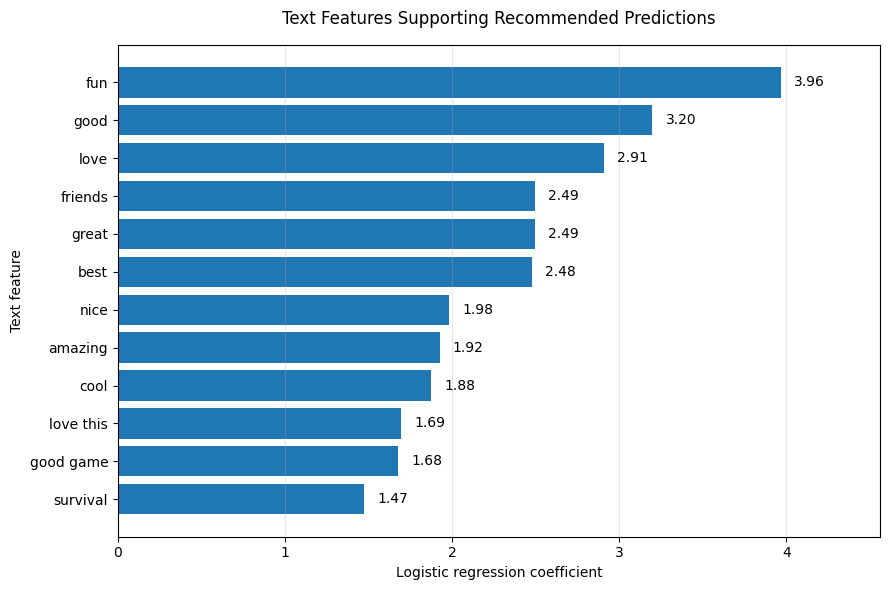

In [21]:
positive_plot = (
    final_positive_features
    .sort_values("coefficient")
)

figure, axis = plt.subplots(figsize=(9, 6))

bars = axis.barh(
    positive_plot["term"],
    positive_plot["coefficient"],
)

axis.set_title(
    "Text Features Supporting Recommended Predictions",
    pad=15,
)
axis.set_xlabel("Logistic regression coefficient")
axis.set_ylabel("Text feature")
axis.grid(
    axis="x",
    alpha=0.3,
)

maximum_value = positive_plot["coefficient"].max()

axis.set_xlim(
    0,
    maximum_value * 1.15,
)

for bar, value in zip(
    bars,
    positive_plot["coefficient"],
):
    axis.text(
        bar.get_width() + maximum_value * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
    )

figure.tight_layout()

figure.savefig(
    figures_dir / "14_model_positive_features.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

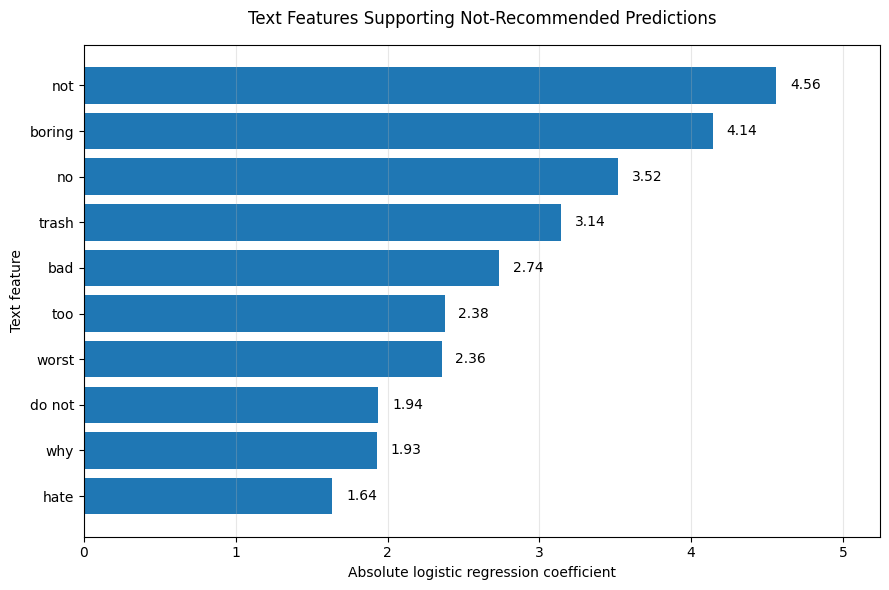

In [22]:
negative_plot = (
    final_negative_features
    .copy()
)

negative_plot["coefficient_magnitude"] = (
    negative_plot["coefficient"].abs()
)

negative_plot = negative_plot.sort_values(
    "coefficient_magnitude"
)

figure, axis = plt.subplots(figsize=(9, 6))

bars = axis.barh(
    negative_plot["term"],
    negative_plot["coefficient_magnitude"],
)

axis.set_title(
    "Text Features Supporting Not-Recommended Predictions",
    pad=15,
)
axis.set_xlabel("Absolute logistic regression coefficient")
axis.set_ylabel("Text feature")
axis.grid(
    axis="x",
    alpha=0.3,
)

maximum_value = (
    negative_plot["coefficient_magnitude"].max()
)

axis.set_xlim(
    0,
    maximum_value * 1.15,
)

for bar, value in zip(
    bars,
    negative_plot["coefficient_magnitude"],
):
    axis.text(
        bar.get_width() + maximum_value * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
    )

figure.tight_layout()

figure.savefig(
    figures_dir / "15_model_negative_features.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

逻辑回归模型主要通过明确的评价词和体验表达区分好评与差评。
在好评预测中，影响较大的特征包括 fun、good、love、friends、great 和 best。这与前面的主题分析结果一致，说明乐趣体验、正面评价和多人游玩是推荐该游戏的重要语言信号。
在差评预测中，not、no、boring、trash、bad 和 worst 等词具有较强影响。其中，boring 与前面识别出的“重复和无聊”问题一致。not 和 no 属于否定词，本身不代表具体问题，但可以帮助模型识别否定句。
逻辑回归系数反映一个文本特征对分类方向的影响，不等同于概率，也不能被解释为某个词直接导致玩家给出好评或差评。

In [23]:
prediction_probabilities = text_model.predict_proba(
    X_test
)

prediction_results = pd.DataFrame(
    {
        "review": X_test,
        "actual": y_test,
        "predicted": model_predictions,
        "probability_not_recommended": (
            prediction_probabilities[:, 0]
        ),
        "probability_recommended": (
            prediction_probabilities[:, 1]
        ),
    },
    index=X_test.index,
)

prediction_results["actual_label"] = (
    prediction_results["actual"]
    .map(
        {
            0: "Not recommended",
            1: "Recommended",
        }
    )
)

prediction_results["predicted_label"] = (
    prediction_results["predicted"]
    .map(
        {
            0: "Not recommended",
            1: "Recommended",
        }
    )
)

prediction_results.head()

,review,actual,predicted,probability_not_recommended,probability_recommended,actual_label,predicted_label
1896,I liked that this game gives me an option to light a fire under a crock pot. And I was quite surprised when instead ...,0,0,0.817757,0.182243,Not recommended,Not recommended
703,"one eyed fellow came to say hello to me. not friendly, world gone, heart shattered",1,1,0.491689,0.508311,Recommended,Recommended
3233,"Good game overall, one specific problem: trolls.",1,1,0.189353,0.810647,Recommended,Recommended
1795,have 27 hours but still didn't defeat any bosses(longest pasifist run ever),1,1,0.291349,0.708651,Recommended,Recommended
4474,"It's not a new game and it still has a small-budget feel, but it remains one of the best multiplayer games around. A...",1,1,0.343212,0.656788,Recommended,Recommended


In [24]:
positive_misclassified = (
    prediction_results.loc[
        (prediction_results["actual"] == 1)
        & (prediction_results["predicted"] == 0)
    ]
    .sort_values(
        "probability_not_recommended",
        ascending=False,
    )
    .copy()
)

print(
    "真实好评被误判为差评:",
    len(positive_misclassified),
)

真实好评被误判为差评: 88


In [25]:
negative_misclassified = (
    prediction_results.loc[
        (prediction_results["actual"] == 0)
        & (prediction_results["predicted"] == 1)
    ]
    .sort_values(
        "probability_recommended",
        ascending=False,
    )
    .copy()
)

print(
    "真实差评被误判为好评:",
    len(negative_misclassified),
)

真实差评被误判为好评: 27


In [26]:
positive_error_examples = (
    positive_misclassified[
        [
            "review",
            "actual_label",
            "predicted_label",
            "probability_not_recommended",
        ]
    ]
    .head(10)
    .copy()
)

positive_error_examples["review"] = (
    positive_error_examples["review"]
    .str.replace(r"\s+", " ", regex=True)
    .str.slice(0, 500)
)

ipy_display(
    positive_error_examples.round(3)
)

,review,actual_label,predicted_label,probability_not_recommended
1345,"Honestly, I do not like this game because you do not have 1 minute in this game where you can chill. Chilling and ca...",Recommended,Not recommended,0.878
223,played with my gf. Found a big ass bird sitting on an egg. walked near him and proceeded to pluck me to death immedi...,Recommended,Not recommended,0.804
866,"Good for one or several evening runs with friends, and not for long. One thing, what I don't like in the game is tha...",Recommended,Not recommended,0.801
1362,what the ♥♥♥♥ do i even do,Recommended,Not recommended,0.796
3420,---{ Graphics }--- ☐ You forget what reality is ☐ Beautiful ☑ Good ☐ Decent ☐ Bad ☐ Don‘t look too long at it ☐ MS-D...,Recommended,Not recommended,0.784
1305,alright so this game. the thing that really grabbed me was the whole lore behind the shadow vs moon conflict. you ge...,Recommended,Not recommended,0.780
1205,I hate this game,Recommended,Not recommended,0.760
1593,"My friend gifted me this game, I have no clue what the ♥♥♥♥ I doing, I just wandering around like the meme John Trav...",Recommended,Not recommended,0.714
1638,"lock in and crossplay this bad boy, let them unite,",Recommended,Not recommended,0.710
3004,nothing special only stuf what piple can lurn is how thay need to survival.and thet is can yuse in dificult game sam...,Recommended,Not recommended,0.710


In [27]:
negative_error_examples = (
    negative_misclassified[
        [
            "review",
            "actual_label",
            "predicted_label",
            "probability_recommended",
        ]
    ]
    .head(10)
    .copy()
)

negative_error_examples["review"] = (
    negative_error_examples["review"]
    .str.replace(r"\s+", " ", regex=True)
    .str.slice(0, 500)
)

ipy_display(
    negative_error_examples.round(3)
)

,review,actual_label,predicted_label,probability_recommended
936,Messi the goat,Not recommended,Recommended,0.753
1713,meh,Not recommended,Recommended,0.749
2154,meh,Not recommended,Recommended,0.749
608,WEIRD,Not recommended,Recommended,0.734
3836,its ♥♥♥♥♥♥♥♥,Not recommended,Recommended,0.727
2334,"eh, its aight",Not recommended,Recommended,0.727
2529,tallbirds. racist walrus...,Not recommended,Recommended,0.726
1263,Being a ghost is 50% of my playtime.,Not recommended,Recommended,0.704
3404,i cant recommend this game to most people but if your friends aren't neurotypical its good,Not recommended,Recommended,0.701
1140,more like let's starve together at night. wtf is this game,Not recommended,Recommended,0.697


In [28]:
positive_misclassified.to_csv(
    tables_dir / "misclassified_positive_reviews.csv",
    index=False,
    encoding="utf-8-sig",
)

negative_misclassified.to_csv(
    tables_dir / "misclassified_negative_reviews.csv",
    index=False,
    encoding="utf-8-sig",
)

print("错误案例已保存。")

错误案例已保存。


模型将 88 条真实好评误判为差评，并将 27 条真实差评误判为好评。
真实好评被误判的主要原因包括评论中的反讽、玩笑、负面游戏情境和混合评价。例如，一些玩家虽然选择推荐游戏，但正文中使用了 “I hate this game” 或 “I do not like this game” 等负面表达。部分评论同时包含优点和缺点，基础 TF-IDF 模型难以判断整段评论的最终立场。
真实差评被误判的主要原因是评论过短、表达含蓄或缺少明显负面词。例如 “meh” 和 “WEIRD” 等评论无法为模型提供足够的上下文。有些不满通过具体游戏经历间接表达，而不是使用明确的情感词。
此外，当前文本处理方法主要使用英文单词和双词词组，无法充分利用表情符号、长距离上下文、反讽和转折关系。这说明逻辑回归模型能够识别常见情感表达，但对复杂语境的理解能力有限。
部分误判也可能来自评论标签和正文内容不一致，因此模型错误不完全等同于模型本身的判断失败。

In [29]:
baseline_report_df = pd.DataFrame(
    classification_report(
        y_test,
        baseline_predictions,
        target_names=[
            "Not recommended",
            "Recommended",
        ],
        zero_division=0,
        output_dict=True,
    )
).transpose()

baseline_report_df.round(3)

,precision,recall,f1-score,support
Not recommended,0.000,0.000,0.000,84.000
Recommended,0.907,1.000,0.951,819.000
accuracy,0.907,0.907,0.907,0.907
macro avg,0.453,0.500,0.476,903.000
weighted avg,0.823,0.907,0.863,903.000


In [30]:
model_comparison = pd.DataFrame(
    {
        "Baseline": {
            "Accuracy": baseline_report_df.loc[
                "accuracy",
                "f1-score",
            ],
            "Macro F1": baseline_report_df.loc[
                "macro avg",
                "f1-score",
            ],
            "Negative precision": baseline_report_df.loc[
                "Not recommended",
                "precision",
            ],
            "Negative recall": baseline_report_df.loc[
                "Not recommended",
                "recall",
            ],
            "Negative F1": baseline_report_df.loc[
                "Not recommended",
                "f1-score",
            ],
            "Positive F1": baseline_report_df.loc[
                "Recommended",
                "f1-score",
            ],
        },
        "TF-IDF Logistic Regression": {
            "Accuracy": model_report_df.loc[
                "accuracy",
                "f1-score",
            ],
            "Macro F1": model_report_df.loc[
                "macro avg",
                "f1-score",
            ],
            "Negative precision": model_report_df.loc[
                "Not recommended",
                "precision",
            ],
            "Negative recall": model_report_df.loc[
                "Not recommended",
                "recall",
            ],
            "Negative F1": model_report_df.loc[
                "Not recommended",
                "f1-score",
            ],
            "Positive F1": model_report_df.loc[
                "Recommended",
                "f1-score",
            ],
        },
    }
)

model_comparison.round(3)

,Baseline,TF-IDF Logistic Regression
Accuracy,0.907,0.873
Macro F1,0.476,0.712
Negative precision,0.000,0.393
Negative recall,0.000,0.679
Negative F1,0.000,0.498
Positive F1,0.951,0.927


In [31]:
model_comparison.to_csv(
    tables_dir / "model_comparison.csv"
)

print(
    "模型对比表已保存到:",
    tables_dir / "model_comparison.csv",
)

模型对比表已保存到: /Users/zhouzhou/Desktop/dst-review-analysis/outputs/tables/model_comparison.csv


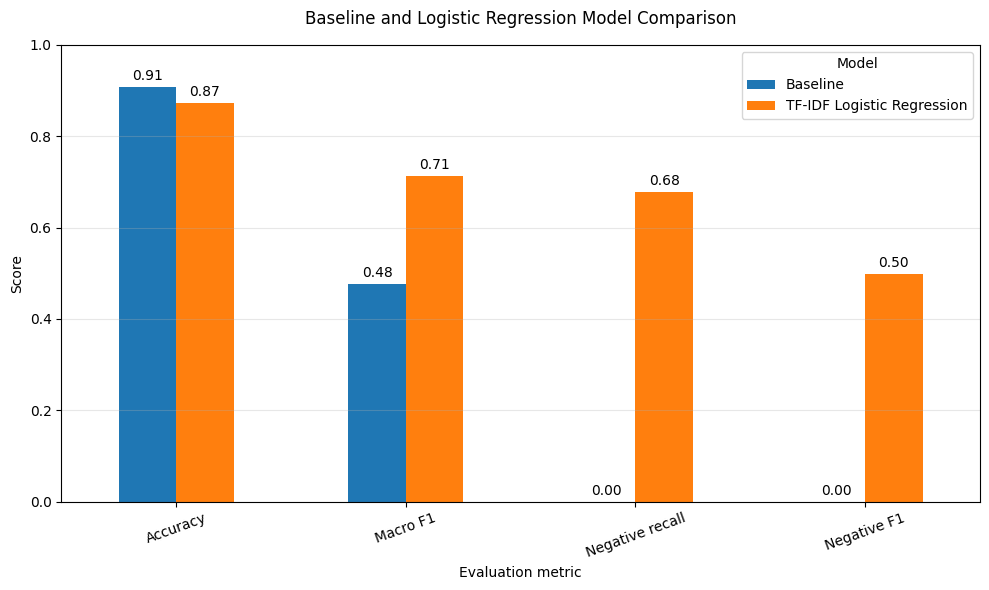

In [32]:
comparison_metrics = [
    "Accuracy",
    "Macro F1",
    "Negative recall",
    "Negative F1",
]

comparison_plot_data = (
    model_comparison.loc[comparison_metrics]
)

figure, axis = plt.subplots(figsize=(10, 6))

comparison_plot_data.plot(
    kind="bar",
    ax=axis,
)

axis.set_title(
    "Baseline and Logistic Regression Model Comparison",
    pad=15,
)
axis.set_xlabel("Evaluation metric")
axis.set_ylabel("Score")
axis.set_ylim(0, 1)
axis.tick_params(
    axis="x",
    rotation=20,
)
axis.grid(
    axis="y",
    alpha=0.3,
)
axis.legend(
    title="Model",
)

for container in axis.containers:
    axis.bar_label(
        container,
        fmt="%.2f",
        padding=3,
    )

figure.tight_layout()

figure.savefig(
    figures_dir / "16_model_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

基线模型的准确率约为 90.7%，高于逻辑回归模型的 87.3%。但是，基线模型把所有评论都预测为好评，因此无法识别任何真实差评。
TF-IDF 逻辑回归模型成功识别了 84 条真实差评中的 57 条，差评召回率达到 67.9%。差评类别的 F1-score 从 0 提升到 0.498，宏平均 F1-score 也提高到 0.712。
虽然逻辑回归模型的整体准确率略有下降，但它能够识别多数差评，因此比基线模型具有更高的实际分析价值。对于当前类别不平衡的数据集，宏平均 F1-score 和差评召回率比准确率更适合作为主要评价指标。